In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Agar plot tampil rapi
plt.rcParams['figure.figsize'] = (8, 6)

In [2]:
wine = load_wine()

# Konversi ke DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print("Dataset shape:", df.shape)
print("Fitur:", wine.feature_names)
print("Target names:", wine.target_names)

Dataset shape: (178, 14)
Fitur: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target names: ['class_0' 'class_1' 'class_2']


In [3]:
print("\n=== Informasi Dataset ===")
df.info()

# Statistik deskriptif
print("\n=== Statistik Deskriptif ===")
print(df.describe())

# Cek missing value
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Cek data duplikat
print("\n=== Data Duplikat ===")
print("Jumlah data duplikat:", df.duplicated().sum())

# Distribusi kelas target
print("\n=== Distribusi Kelas Target ===")
print("Nama kelas:", wine.target_names)
print(df['target'].value_counts())




=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non

In [4]:
X = wine.data  # Fitur
y = wine.target  # Label

print("\n=== Pemisahan Fitur dan Label ===")
print("Shape X:", X.shape)
print("Shape y:", y.shape)


=== Pemisahan Fitur dan Label ===
Shape X: (178, 13)
Shape y: (178,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n=== Train-Test Split ===")
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)


=== Train-Test Split ===
Shape X_train: (142, 13)
Shape X_test: (36, 13)
Shape y_train: (142,)
Shape y_test: (36,)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n=== Standardisasi Data ===")
print("Contoh 5 baris pertama data training yang sudah distandardisasi:")
print(X_train_scaled[:5])


=== Standardisasi Data ===
Contoh 5 baris pertama data training yang sudah distandardisasi:
[[ 0.38580089 -0.63787118  1.77666817 -1.22453161  0.69643032  0.52686525
   0.73229212 -0.1695489  -0.41578344 -0.16746725  0.62437819  0.2529082
   0.46772474]
 [ 0.94851892 -0.76544542  1.25317383  0.85328406  0.09178497  1.17279546
   1.33318146 -0.59045701  1.34974202  0.30530313  1.06715537  0.15104809
   1.81576773]
 [ 0.52335419 -0.51940939  0.9540342  -1.04643312 -0.44567755  0.93057163
   1.006382   -0.1695489  -0.26000178 -0.081509   -0.12834302  0.89317174
   1.51620262]
 [ 0.97352861 -0.55585917  0.16879269 -1.0761162  -0.71440882  0.52686525
   0.81662747 -0.59045701  0.36312485  0.262324    0.8900445   0.42752553
   1.93226527]
 [ 0.43582027  0.82012009  0.05661533  0.55645325 -0.51286037 -0.55506784
  -1.29175618  0.75644894 -0.60618325  1.47433535 -1.76661859 -1.43505932
  -0.29783054]]


In [7]:
print("\n" + "="*50)
print("7. MODEL SVM TANPA PCA (BASELINE)")
print("="*50)

# Membuat dan melatih model SVM tanpa PCA
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

# Prediksi dan evaluasi
y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
print(f"Akurasi SVM tanpa PCA: {acc_no_pca:.4f}")

print("\nClassification Report (tanpa PCA):")
print(classification_report(y_test, y_pred_no_pca, target_names=wine.target_names))


7. MODEL SVM TANPA PCA (BASELINE)
Akurasi SVM tanpa PCA: 0.9722

Classification Report (tanpa PCA):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [8]:
print("\n" + "="*50)
print("8. PENERAPAN PCA (3 KOMPONEN UTAMA)")
print("="*50)

# Menerapkan PCA dengan 3 komponen utama
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape X_train_pca:", X_train_pca.shape)
print("Shape X_test_pca:", X_test_pca.shape)



8. PENERAPAN PCA (3 KOMPONEN UTAMA)
Shape X_train_pca: (142, 3)
Shape X_test_pca: (36, 3)



=== Explained Variance Ratio ===
PC1: 0.3579 (35.79%)
PC2: 0.1927 (19.27%)
PC3: 0.1102 (11.02%)

Total variansi yang dijelaskan 3 komponen pertama: 0.6608 (66.08%)


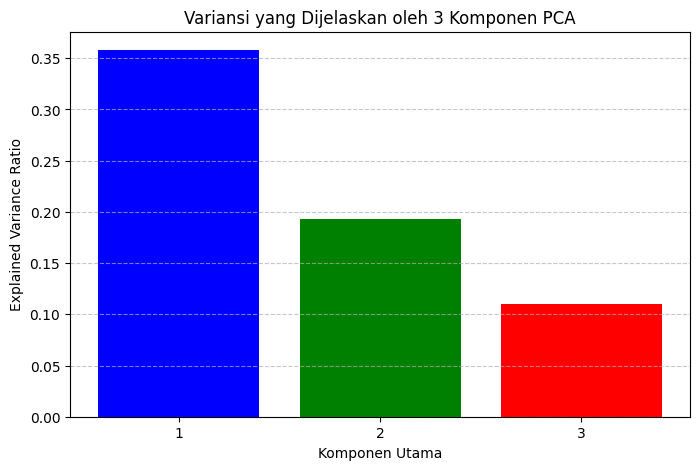

In [9]:
explained_var = pca.explained_variance_ratio_

print("\n=== Explained Variance Ratio ===")
for i, var in enumerate(explained_var, 1):
    print(f"PC{i}: {var:.4f} ({var*100:.2f}%)")

total_var = explained_var.sum()
print(f"\nTotal variansi yang dijelaskan 3 komponen pertama: {total_var:.4f} ({total_var*100:.2f}%)")

# Visualisasi explained variance ratio
plt.figure(figsize=(8, 5))
plt.bar(range(1, 4), explained_var, color=['blue', 'green', 'red'])
plt.xlabel('Komponen Utama')
plt.ylabel('Explained Variance Ratio')
plt.title('Variansi yang Dijelaskan oleh 3 Komponen PCA')
plt.xticks([1, 2, 3])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [10]:
print("\n" + "="*50)
print("10. MODEL SVM DENGAN PCA")
print("="*50)

# Membuat dan melatih model SVM dengan PCA
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

# Prediksi dan evaluasi
y_pred_pca = svm_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, y_pred_pca)
print(f"Akurasi SVM dengan PCA (3 komponen): {acc_pca:.4f}")

print("\nClassification Report (dengan PCA):")
print(classification_report(y_test, y_pred_pca, target_names=wine.target_names))


10. MODEL SVM DENGAN PCA
Akurasi SVM dengan PCA (3 komponen): 0.9722

Classification Report (dengan PCA):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36




11. VISUALISASI PCA DALAM RUANG 3D


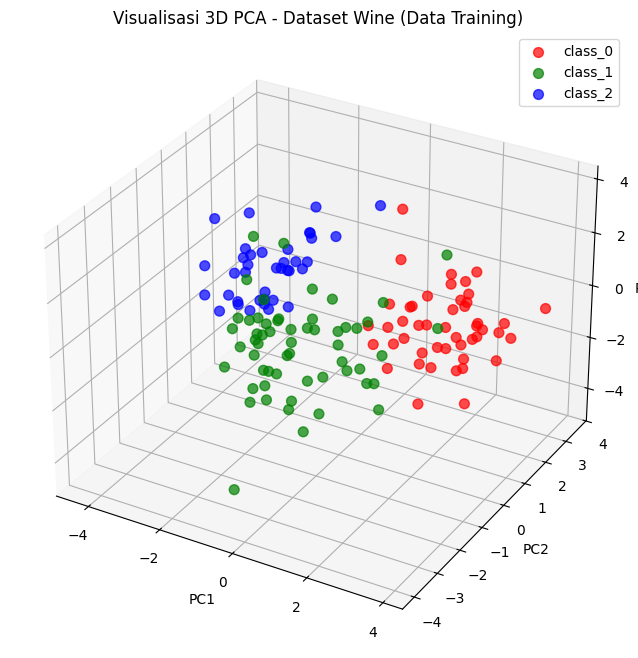

In [12]:
print("\n" + "="*50)
print("11. VISUALISASI PCA DALAM RUANG 3D")
print("="*50)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Warna untuk setiap kelas
colors = ['red', 'green', 'blue']
labels = wine.target_names

# Plot setiap kelas
for i, color in enumerate(colors):
    # Gunakan y_train untuk masking karena X_train_pca berasal dari data training
    idx = (y_train == i)
    ax.scatter(X_train_pca[idx, 0], X_train_pca[idx, 1], X_train_pca[idx, 2],
               c=color, label=labels[i], alpha=0.7, s=50)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Visualisasi 3D PCA - Dataset Wine (Data Training)')
ax.legend()
plt.show()


12. PERBANDINGAN MODEL

=== Perbandingan Model SVM ===
                     Model  Jumlah Fitur   Akurasi  Variansi Dijelaskan
0                Tanpa PCA            13  0.972222             1.000000
1  Dengan PCA (3 Komponen)             3  0.972222             0.660826


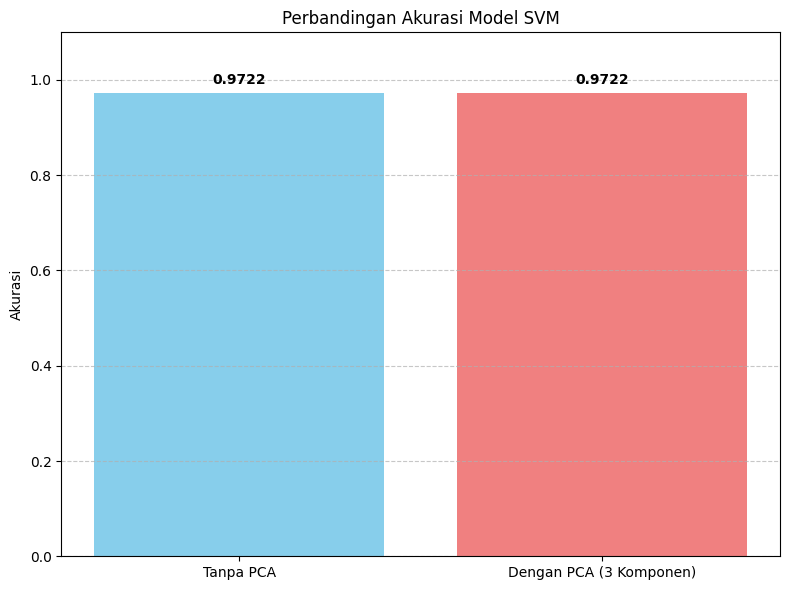

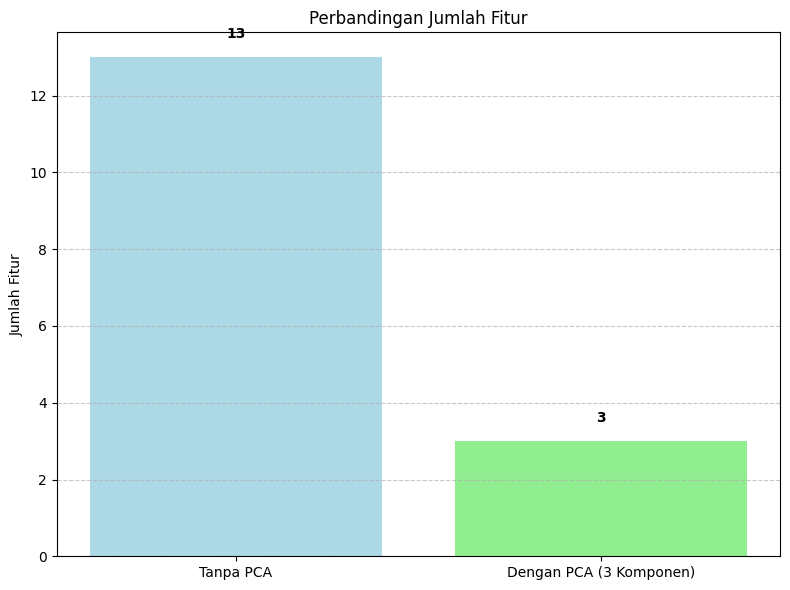

In [13]:
print("\n" + "="*50)
print("12. PERBANDINGAN MODEL")
print("="*50)

# Data perbandingan
models = ['Tanpa PCA', 'Dengan PCA (3 Komponen)']
accuracies = [acc_no_pca, acc_pca]
features = [X.shape[1], 3]  # Jumlah fitur
variance_explained = [1.0, total_var]  # Variansi yang dijelaskan

# Tabel perbandingan
comparison_df = pd.DataFrame({
    'Model': models,
    'Jumlah Fitur': features,
    'Akurasi': accuracies,
    'Variansi Dijelaskan': variance_explained
})

print("\n=== Perbandingan Model SVM ===")
print(comparison_df)

# Visualisasi perbandingan akurasi
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['skyblue', 'lightcoral'])
plt.title('Perbandingan Akurasi Model SVM')
plt.ylabel('Akurasi')
plt.ylim(0, 1.1)

# Menambahkan nilai di atas bar
for i, (model, acc) in enumerate(zip(models, accuracies)):
    plt.text(i, acc + 0.02, f'{acc:.4f}', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualisasi perbandingan jumlah fitur
plt.figure(figsize=(8, 6))
plt.bar(models, features, color=['lightblue', 'lightgreen'])
plt.title('Perbandingan Jumlah Fitur')
plt.ylabel('Jumlah Fitur')

# Menambahkan nilai di atas bar
for i, (model, feat) in enumerate(zip(models, features)):
    plt.text(i, feat + 0.5, str(feat), ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [14]:
print("\n" + "="*50)
print("KESIMPULAN PRAKTIKUM PCA")
print("="*50)

print(f"""
Hasil Analisis:

1. Reduksi Dimensi:
   - Fitur awal: {X.shape[1]} fitur
   - Setelah PCA: 3 komponen utama
   - Pengurangan: {((X.shape[1] - 3) / X.shape[1] * 100):.1f}%

2. Variansi yang Dijelaskan:
   - PC1: {explained_var[0]*100:.2f}%
   - PC2: {explained_var[1]*100:.2f}%
   - PC3: {explained_var[2]*100:.2f}%
   - Total: {total_var*100:.2f}%

3. Kinerja Model:
   - Akurasi tanpa PCA: {acc_no_pca:.4f}
   - Akurasi dengan PCA: {acc_pca:.4f}
   - Perbedaan akurasi: {abs(acc_no_pca - acc_pca):.4f}

4. Efisiensi:
   - Dengan PCA, model menggunakan {((3/X.shape[1])*100):.1f}% dari fitur asli
   - Namun tetap mempertahankan {acc_pca*100:.2f}% akurasi

KESIMPULAN:
PCA berhasil mereduksi dimensi dari {X.shape[1]} fitur menjadi 3 komponen utama
yang menjelaskan {total_var*100:.2f}% variansi data, tanpa mengurangi performa
model secara signifikan (akurasi tetap {acc_pca*100:.2f}%).
""")




KESIMPULAN PRAKTIKUM PCA

Hasil Analisis:

1. Reduksi Dimensi:
   - Fitur awal: 13 fitur
   - Setelah PCA: 3 komponen utama
   - Pengurangan: 76.9%

2. Variansi yang Dijelaskan:
   - PC1: 35.79%
   - PC2: 19.27%
   - PC3: 11.02%
   - Total: 66.08%

3. Kinerja Model:
   - Akurasi tanpa PCA: 0.9722
   - Akurasi dengan PCA: 0.9722
   - Perbedaan akurasi: 0.0000

4. Efisiensi:
   - Dengan PCA, model menggunakan 23.1% dari fitur asli
   - Namun tetap mempertahankan 97.22% akurasi

KESIMPULAN:
PCA berhasil mereduksi dimensi dari 13 fitur menjadi 3 komponen utama
yang menjelaskan 66.08% variansi data, tanpa mengurangi performa
model secara signifikan (akurasi tetap 97.22%).

